# 05. Retrieval Engineering
## Dense → BM25 → Hybrid → RRF

### 이번 실습의 위치

```text
01 Naive RAG
    ↓
02 Document Processing
    ↓
03 Query Rewriting
    ↓
04 Multi Query
    ↓
05 Retrieval Engineering
   Dense + BM25 + RRF
    ↓
06 Reranking
```

이번 실습의 목적은 **검색기 자체를 개선하는 방법**을 이해하는 것이다.

### 학습 목표

실습 후 다음 네 가지를 설명할 수 있으면 충분하다.

1. Dense Retrieval과 BM25의 차이
2. Hybrid Retrieval이 필요한 이유
3. 서로 다른 검색 점수를 직접 합치기 어려운 이유
4. RRF가 검색 결과의 **순위(rank)** 를 결합하는 방법

> 핵심: **Dense는 의미를 찾고, BM25는 정확한 단어를 찾으며, RRF는 두 검색 결과의 순위를 결합한다.**


# 1. 환경 설정

02번 실습에서 만든 ChromaDB를 그대로 사용한다.

Dense와 BM25를 공정하게 비교하기 위해 **동일한 chunk corpus**를 사용한다.

필요 패키지:

```bash
uv add langchain-chroma rank-bm25
```


In [1]:
import sys
import re
from pathlib import Path

from langchain_chroma import Chroma
from langchain_core.documents import Document
from rank_bm25 import BM25Okapi

# 상위 폴더의 common_config 모듈을 불러오기 위해 경로를 추가한다.
sys.path.append("..")
from common_config import embedding_model


# 02번 실습에서 저장한 ChromaDB 경로와 컬렉션 이름
DB_PATH = Path("chroma_db/ai_trend_report_doc_chunks")
COLLECTION_NAME = "ai_trend_report_2026_doc_chunks"

# DB가 없으면 이후 검색을 할 수 없으므로 먼저 02번 실습을 실행하도록 안내한다.
if not DB_PATH.exists():
    raise FileNotFoundError(
        "02_document_processing_docling_chunks.ipynb를 먼저 실행하세요."
    )

# 임베딩 모델을 생성한다. (Dense 검색에서 Query와 chunk를 벡터로 바꾸는 데 사용)
embeddings = embedding_model()

# 저장된 ChromaDB 컬렉션을 불러온다. (새로 만들지 않고 기존 데이터를 사용)
vector_store = Chroma(
    collection_name=COLLECTION_NAME,
    embedding_function=embeddings,
    persist_directory=str(DB_PATH),
)

# 저장된 chunk 개수를 확인한다.
print("저장된 chunk 수:", vector_store._collection.count())


저장된 chunk 수: 48


# 2. Dense Retrieval

Dense Retrieval은 Query와 Document를 embedding vector로 변환한 뒤,
벡터 공간에서 가까운 문서를 찾는 **의미 기반 검색(Semantic Search)** 이다.

```text
Query
  ↓
Embedding
  ↓
Vector Search
  ↓
Top-k Documents
```

### 특징

- 표현이 달라도 의미가 비슷하면 찾을 수 있다.
- 자연어 질문에 강하다.
- 정확한 정책명·제품명·전문용어 검색에서는 놓치는 문서가 생길 수 있다.


In [2]:
def dense_search(query, k=5):
    # Query를 embedding으로 바꾼 뒤, 벡터 거리가 가까운 문서 k개를 찾는다.
    return vector_store.similarity_search(query, k=k)


# 3. BM25 Retrieval

BM25는 embedding을 사용하지 않고 Query의 단어와 문서의 단어가 얼마나 잘 일치하는지를 계산하는
**키워드 기반 검색(Lexical Search)** 이다.

```text
Query Terms
    ↓
Keyword Matching
    ↓
BM25 Score
    ↓
Top-k Documents
```

### Dense와 BM25의 차이

| 방법 | 검색 기준 | 강점 |
|---|---|---|
| Dense | 의미(Semantic) | 자연어 질문, 의미가 비슷한 표현 |
| BM25 | 단어(Lexical) | 정책명, 전문용어, 고유명사 |

예: `AI 기본법`, `EU AI Act`, `One-Source Multi-Use`


In [3]:
# ChromaDB에 저장된 chunk(문서 본문과 메타데이터)를 모두 가져온다.
stored = vector_store.get(
    include=["documents", "metadatas"]
)

# Dense와 BM25가 같은 문서를 사용하도록 Document 목록을 만든다.
corpus_docs = []

for text, metadata in zip(
    stored["documents"],
    stored["metadatas"],
):
    doc = Document(
        page_content=text,
        metadata=metadata or {},  # metadata가 None이면 빈 dict로 대체
    )
    corpus_docs.append(doc)


# BM25는 단어 단위로 검색하므로 소문자로 바꾼 뒤 단어(\w+)만 추출한다.
def tokenize(text):
    return re.findall(r"\w+", text.lower())


# 모든 chunk를 토큰 리스트로 바꾼다. (BM25는 토큰 리스트를 입력으로 받는다)
tokenized_corpus = []

for doc in corpus_docs:
    tokens = tokenize(doc.page_content)
    tokenized_corpus.append(tokens)


# 토큰화된 corpus로 BM25 검색기를 생성한다.
bm25 = BM25Okapi(tokenized_corpus)

print("BM25 문서 수:", len(corpus_docs))


BM25 문서 수: 48


In [4]:
def bm25_search(query, k=5):
    # 질문도 corpus와 같은 방식으로 토큰화한다.
    query_tokens = tokenize(query)

    # 질문 토큰과 가장 잘 맞는 BM25 점수 상위 k개 문서를 반환한다.
    return bm25.get_top_n(
        query_tokens,
        corpus_docs,
        n=k,
    )


# 4. Dense vs BM25 비교

차이를 보기 위해 질문은 **두 종류만** 사용한다.

```text
의미 중심 질문
→ Dense의 강점을 확인

정확한 용어 중심 질문
→ BM25의 강점을 확인
```

중요한 것은 어느 검색기가 항상 더 좋다고 결론내리는 것이 아니다.

> **질문의 성격에 따라 Dense와 BM25가 서로 다른 관련 문서를 찾을 수 있다.**


In [5]:
def print_results(title, docs):
    # 검색 방식 이름(title)과 함께 결과 문서의 chunk 번호와 페이지를 출력한다.
    print(f"\n[{title}]")

    for rank, doc in enumerate(docs, start=1):
        print(
            f"{rank}. "
            f"chunk={doc.metadata.get('chunk_id')} "
            f"| pages={doc.metadata.get('pages')}"
        )


# Dense가 유리할 수 있는 의미 중심 질문
query1 = "기업 내부에서 AI가 업무에 어떻게 활용될 것으로 전망되나요?"

# 같은 질문에 대해 Dense와 BM25의 결과를 각각 상위 3개씩 비교한다.
dense_docs = dense_search(query1, k=3)
bm25_docs = bm25_search(query1, k=3)

print("\nQUERY:", query1)
print_results("Dense", dense_docs)
print_results("BM25", bm25_docs)


# BM25가 유리할 수 있는 정확한 용어 중심 질문
query2 = "One-Source Multi-Use는 어떤 맥락에서 제시되었나요?"

# 두 번째 질문도 같은 방식으로 Dense와 BM25 결과를 비교한다.
dense_docs = dense_search(query2, k=3)
bm25_docs = bm25_search(query2, k=3)

print("\nQUERY:", query2)
print_results("Dense", dense_docs)
print_results("BM25", bm25_docs)



QUERY: 기업 내부에서 AI가 업무에 어떻게 활용될 것으로 전망되나요?

[Dense]
1. chunk=38 | pages=17
2. chunk=39 | pages=18
3. chunk=10 | pages=5

[BM25]
1. chunk=38 | pages=17
2. chunk=11 | pages=6
3. chunk=13 | pages=7

QUERY: One-Source Multi-Use는 어떤 맥락에서 제시되었나요?

[Dense]
1. chunk=8 | pages=5
2. chunk=43 | pages=20
3. chunk=26 | pages=13

[BM25]
1. chunk=43 | pages=20
2. chunk=8 | pages=5
3. chunk=14 | pages=7


# 5. Hybrid Retrieval

Dense와 BM25는 서로 다른 장점이 있다.

따라서 두 검색 결과를 함께 사용하면 검색 후보를 더 다양하게 확보할 수 있다.

```text
                 ┌─ Dense Retrieval
Query ───────────┤
                 └─ BM25 Retrieval
                        ↓
                  Hybrid Retrieval
```

하지만 Dense와 BM25의 **점수 척도는 서로 다르다.**

```text
Dense distance : 0.18, 0.25, 0.31 ...
BM25 score     : 12.4, 8.7, 5.1 ...
```

따라서 두 점수를 그대로 더하거나 평균내는 방식은 적절하지 않다.

이 문제를 간단하게 해결하는 방법 중 하나가 **RRF(Reciprocal Rank Fusion)** 이다.


# 6. RRF — Reciprocal Rank Fusion

RRF는 검색기의 원래 점수를 합치는 것이 아니라 **검색 결과의 순위(rank)** 를 결합한다.

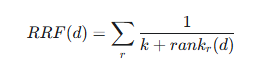
| 기호 | 의미 |
|---|---|
| \(RRF(d)\) | 문서 \(d\)의 최종 RRF 점수 |
| \(\sum\) | **합한다(Summation)**는 의미 |
| \(r\) | 각각의 검색기(Retriever) |
| \(k\) | 순위 영향력을 조절하는 상수, 보통 60 사용 |
| \(rank_r(d)\) | 검색기 \(r\)에서 문서 \(d\)의 순위 |
| \(d\) | 검색된 문서(Document) |

```text
Dense Ranking          BM25 Ranking

D3 → 1위              D1 → 1위
D7 → 2위              D4 → 2위
D1 → 3위              D3 → 3위
       \                 /
        \               /
          ---- RRF ----
               ↓
          Hybrid Ranking
```

즉,

```text
Score Fusion  X
Rank Fusion   O
```

두 검색기에서 반복적으로 상위에 등장하는 문서는 최종 순위에서도 높은 점수를 얻기 쉽다.


In [6]:
def rrf(dense_docs, bm25_docs, k=60):
    # chunk_id별 RRF 점수를 저장한다.
    scores = {}

    # chunk_id로 원래 Document를 다시 찾기 위한 저장소
    documents = {}

    # Dense 결과와 BM25 결과를 차례로 확인한다.
    for result in [dense_docs, bm25_docs]:

        # rank는 1위부터 시작한다.
        for rank, doc in enumerate(result, start=1):
            chunk_id = doc.metadata["chunk_id"]

            # 처음 등장한 chunk라면 점수를 0으로 초기화하고 Document를 저장한다.
            if chunk_id not in scores:
                scores[chunk_id] = 0
                documents[chunk_id] = doc

            # RRF 공식: 검색기별로 1 / (k + rank)를 더한다.
            # 두 검색기에서 모두 상위권이면 점수가 커진다.
            scores[chunk_id] += 1 / (k + rank)

    # RRF 점수가 높은 chunk_id 순서로 정렬한다.
    ranked_ids = sorted(
        scores,
        key=scores.get,
        reverse=True,
    )

    # 정렬된 순서대로 Document 목록을 반환한다.
    return [
        documents[chunk_id]
        for chunk_id in ranked_ids
    ]


# 7. 최종 비교

이제 같은 Query에 대해 세 검색 결과의 **순위만** 비교한다.

```text
Dense
   vs
BM25
   vs
Hybrid + RRF
```

비교할 것은 네 가지이다.

1. Dense가 찾은 상위 문서는 무엇인가?
2. BM25가 찾은 상위 문서는 무엇인가?
3. 두 검색 결과가 서로 다른가?
4. RRF를 적용한 Hybrid 결과에는 어떤 문서가 올라왔는가?


In [7]:
query = "AI 기본법 시행령과 글로벌 규제 정합성은 어떻게 설명되나요?"

# 1. Dense에서 후보 문서 8개를 검색한다.
dense_docs = dense_search(query, k=8)

# 2. BM25에서 후보 문서 8개를 검색한다.
bm25_docs = bm25_search(query, k=8)

# 3. 두 검색 결과의 순위를 RRF로 결합한다.
hybrid_docs = rrf(
    dense_docs,
    bm25_docs,
    k=60,
)

# 4. 최종 Top-5만 사용한다.
hybrid_docs = hybrid_docs[:5]


print("QUERY:", query)

# Dense, BM25, Hybrid 결과의 순위를 나란히 비교한다.
print_results("Dense", dense_docs[:5])
print_results("BM25", bm25_docs[:5])
print_results("Hybrid + RRF", hybrid_docs)


QUERY: AI 기본법 시행령과 글로벌 규제 정합성은 어떻게 설명되나요?

[Dense]
1. chunk=42 | pages=19
2. chunk=47 | pages=21
3. chunk=14 | pages=7
4. chunk=41 | pages=19
5. chunk=13 | pages=7

[BM25]
1. chunk=34 | pages=16
2. chunk=13 | pages=7
3. chunk=14 | pages=7
4. chunk=32 | pages=15
5. chunk=41 | pages=19

[Hybrid + RRF]
1. chunk=14 | pages=7
2. chunk=34 | pages=16
3. chunk=13 | pages=7
4. chunk=42 | pages=19
5. chunk=47 | pages=21


# 8. 핵심 정리와 다음 단계

## 오늘 기억할 것

```text
Dense
→ Semantic Search
→ 의미가 비슷한 문서를 찾는다.

BM25
→ Lexical Search
→ 정확한 단어가 포함된 문서를 찾는다.

Hybrid
→ Dense + BM25
→ 서로 다른 검색 방식의 장점을 함께 사용한다.

RRF
→ Rank Fusion
→ 서로 다른 검색 결과의 순위를 결합한다.
```

## 주의할 점

1. Hybrid가 항상 Dense보다 좋은 것은 아니다.
2. BM25는 tokenizer 품질의 영향을 받는다.
3. RRF는 문서 내용을 다시 판단하는 모델이 아니라 **검색 결과의 순위를 결합하는 방법**이다.

그래서 다음 단계에서 **Reranking**이 필요하다.

```text
Dense + BM25
      ↓
Hybrid Retrieval
      ↓
RRF
      ↓
Candidate Top-N
      ↓
06. Reranking
      ↓
Final Top-k
```

> 05번의 핵심은 **검색 후보를 더 잘 확보하는 것**, 06번의 핵심은 **확보한 후보의 관련성을 다시 평가하는 것**이다.
